# Workforce Analytics Notebook

This notebook analyzes workforce-related data to understand employee patterns.
It starts by loading the dataset and reviewing the available fields.
The workflow then explores trends, comparisons, and useful insights.
Later cells support visualization and simple data preparation steps.


In [1]:
import pandas as pd

In [2]:
df=pd.read_csv(r"C:\MCA\ai\hr_analytics.xls")

In [3]:
df.head()

,Age,Gender,Department,MonthlyIncome,TotalWorkingYears,YearsAtCompany,JobSatisfaction,WorkLifeBalance,OverTime,Attrition
0,50,Female,HR,4753,14,8,2,1,Yes,No
1,36,Male,R&D,13123,3,7,3,4,No,No
2,29,Male,HR,19376,16,15,1,3,Yes,No
3,42,Male,HR,9588,19,14,2,4,No,Yes
4,40,Male,R&D,9304,18,8,2,3,No,Yes


In [4]:
df.dtypes

Age                   int64
Gender               object
Department           object
MonthlyIncome         int64
TotalWorkingYears     int64
YearsAtCompany        int64
JobSatisfaction       int64
WorkLifeBalance       int64
OverTime             object
Attrition            object
dtype: object

In [5]:
df.describe()

,Age,MonthlyIncome,TotalWorkingYears,YearsAtCompany,JobSatisfaction,WorkLifeBalance
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,40.947000,11496.427000,17.518000,10.273000,2.475000,2.463000
std,11.160858,4897.403307,9.585696,5.494967,1.124562,1.101746
min,22.000000,3024.000000,1.000000,1.000000,1.000000,1.000000
25%,31.000000,7240.250000,10.000000,6.000000,1.000000,1.000000
50%,42.000000,11709.000000,17.000000,11.000000,2.000000,2.000000
75%,50.000000,15657.500000,26.000000,15.000000,4.000000,3.000000
max,59.000000,19998.000000,34.000000,19.000000,4.000000,4.000000


In [6]:
df.isnull().sum()

Age                  0
Gender               0
Department           0
MonthlyIncome        0
TotalWorkingYears    0
YearsAtCompany       0
JobSatisfaction      0
WorkLifeBalance      0
OverTime             0
Attrition            0
dtype: int64

In [7]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 1000, dtype: bool

In [9]:
len(df)

1000

In [11]:
df['Department'].nunique()

3

In [12]:
df['Age'].mean()

np.float64(40.947)

In [13]:
df['Age'].min()

np.int64(22)

In [14]:
df['Age'].max()

np.int64(59)

In [17]:
print(round(df['MonthlyIncome'].mean(), 2))

11496.43


In [18]:
df['MonthlyIncome'].max()

np.int64(19998)

In [19]:
df['MonthlyIncome'].min()

np.int64(3024)

In [20]:
df['Gender'].value_counts()

Gender
Male      504
Female    496
Name: count, dtype: int64

In [21]:
df['Department'].value_counts()

Department
HR       352
Sales    343
R&D      305
Name: count, dtype: int64

In [30]:
df[df['TotalWorkingYears']>10].shape[0]

720

In [39]:
(df['YearsAtCompany']>5).shape[0]

1000

In [36]:
dept_salary = df.groupby('Department')['MonthlyIncome'].mean()
print(dept_salary) 

Department
HR       11604.042614
R&D      11461.272131
Sales    11417.247813
Name: MonthlyIncome, dtype: float64


In [44]:
df[df['Attrition']=='Yes'].groupby('Department')['Attrition'].count()

Department
HR       70
R&D      74
Sales    59
Name: Attrition, dtype: int64

In [46]:
df.groupby('Department')['YearsAtCompany'].sum()

Department
HR       3649
R&D      3184
Sales    3440
Name: YearsAtCompany, dtype: int64

In [47]:
#avg job satisfaction by department
df.groupby('Department')['JobSatisfaction'].mean()

Department
HR       2.446023
R&D      2.465574
Sales    2.513120
Name: JobSatisfaction, dtype: float64

In [48]:
#avg job satisfaction and work life balance for each gender
df.groupby('Gender')[['JobSatisfaction', 'WorkLifeBalance']].mean()

,JobSatisfaction,WorkLifeBalance
Gender,,
Female,2.512097,2.463710
Male,2.438492,2.462302


In [1]:
import nltk
from nltk.corpus import RegexpTokenizer
text="hello how are you doing today? #AI @2026"
tokenizer=RegexpTokenizer(r'\w+')
tokens=tokenizer.tokenize(text)
tokens

['hello', 'how', 'are', 'you', 'doing', 'today', 'AI', '2026']

In [4]:
#stop words removal
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
text="this is a sample text for stop words removal"
tokens=word_tokenize(text)
print("Tokens:", tokens)
stop_words=set(stopwords.words("english"))
filtered_tokens=[token for token in tokens if token.lower() not in stop_words]
print("Filtered Tokens:", filtered_tokens)


Tokens: ['this', 'is', 'a', 'sample', 'text', 'for', 'stop', 'words', 'removal']
Filtered Tokens: ['sample', 'text', 'stop', 'words', 'removal']


In [6]:
filtered_words = [word for word in tokens if word.lower() not in stop_words]
print("Filtered Words:", filtered_words)
print("Original Tokens:", tokens)
for i in tokens:
    print(i)

Filtered Words: ['sample', 'text', 'stop', 'words', 'removal']
Original Tokens: ['this', 'is', 'a', 'sample', 'text', 'for', 'stop', 'words', 'removal']
this
is
a
sample
text
for
stop
words
removal


In [8]:
fw=[]
for i in tokens:
    if i not in stop_words:
        fw.append(i)
print("Filtered Words:", fw)

Filtered Words: ['sample', 'text', 'stop', 'words', 'removal']


In [10]:
text="the cat is running fast"
tokens=word_tokenize(text)
pos_tags=nltk.pos_tag(tokens)
# print("POS Tags:", pos_tags)
pos_tags

[('the', 'DT'),
 ('cat', 'NN'),
 ('is', 'VBZ'),
 ('running', 'VBG'),
 ('fast', 'RB')]

(S apple/NN is/VBZ based/VBN in/IN california/NN)


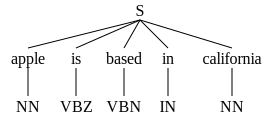

In [14]:
#NER example
from nltk import ne_chunk
text="apple is based in california"
tokens=word_tokenize(text)
pos_tags=nltk.pos_tag(tokens)
ner=ne_chunk(pos_tags)
print(ner)
ner